## <span style="color:blue"> Lezione 3 </span>


In [2]:
from scipy.special import erf
import numpy as np
from numpy import exp
from numpy.lib.scimath import log, sqrt
import matplotlib.pyplot as plt


### <span style="color:DodgerBlue"> Esercizio 3.1  </span>


Nella cella sottostante e' stato copiato il codice che implementa la formula analitica del prezzo delle opzioni, per confronto con la simulazione.

In [3]:

# data
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


Nella cella sottostante, e' implementato il codice che costruisce i grafici delle simulazioni del prezzo delle opzioni, in funzione del numero di blocchi considerati. La simulazione e'stata svolta per opzioni call e put, e calcolando $S(T)$ direttamente da $S(0)$ o discretizzando l'intervallo $[0,T]$ in $R=100$ sottointervalli


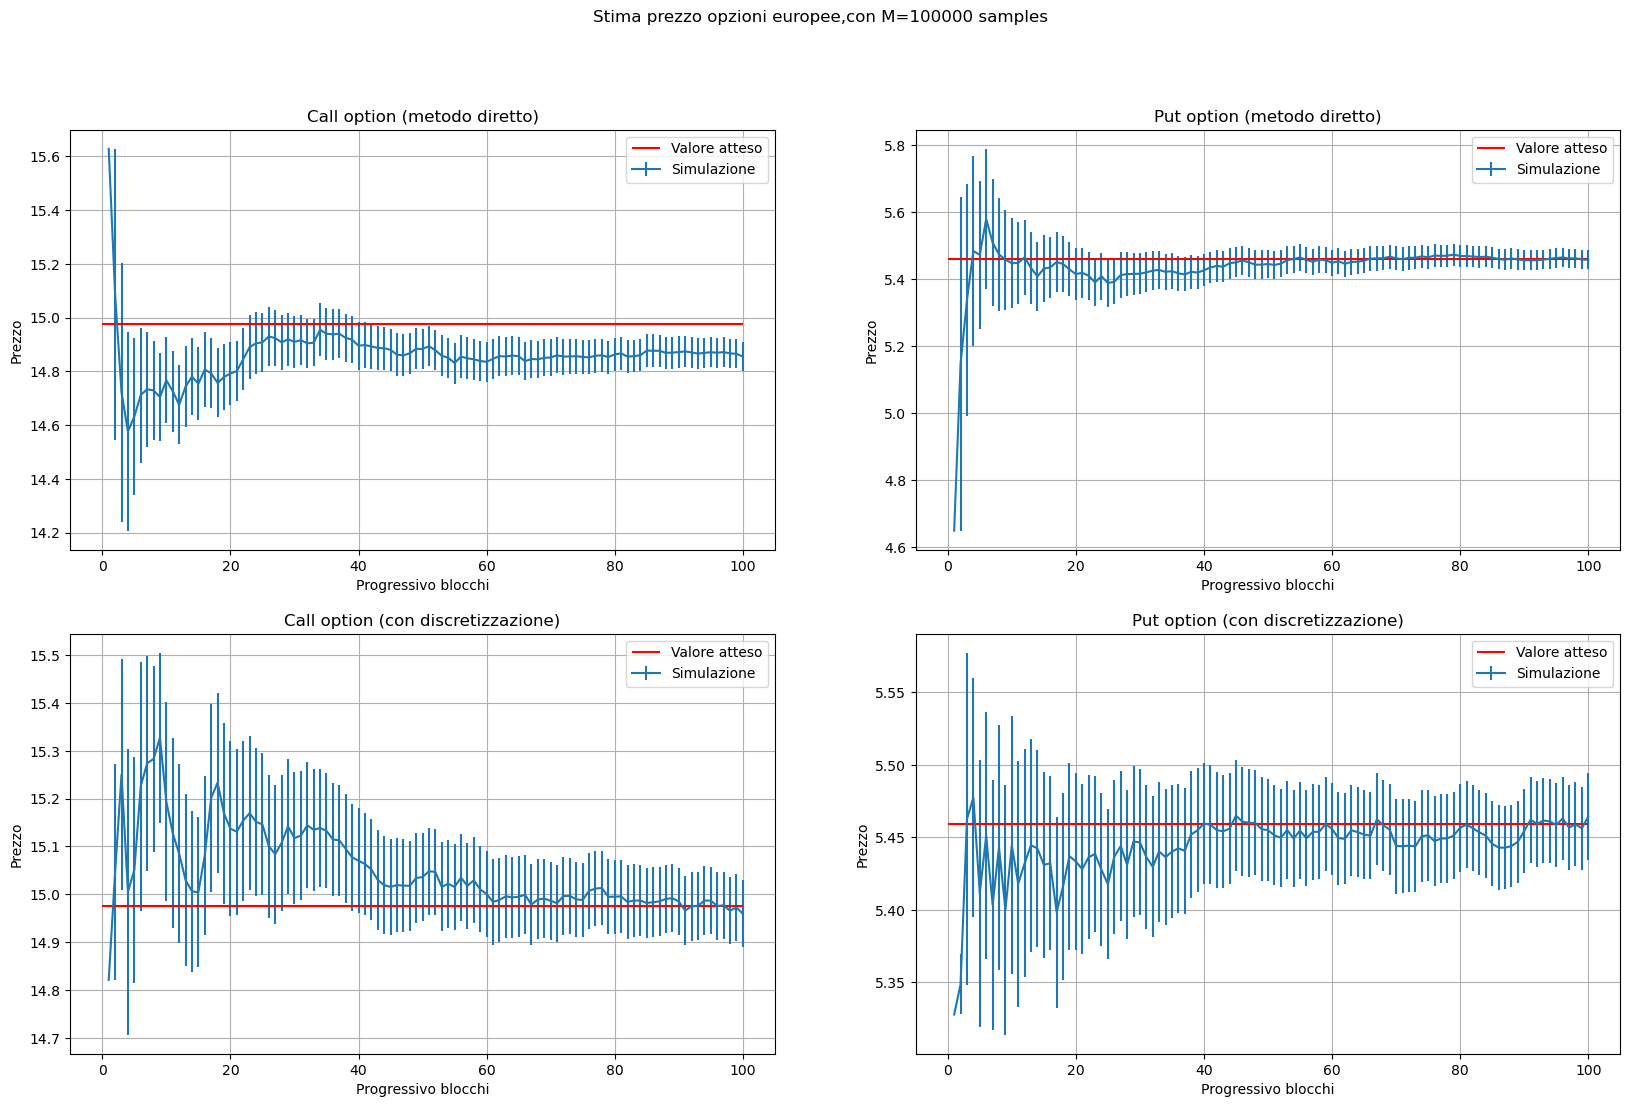

In [4]:


M=100000 #numero samples
N=100 #numero blocchi

titles={0:"Call option (metodo diretto)", 1: "Put option (metodo diretto)", 2:"Call option (con discretizzazione)", 3: "Put option (con discretizzazione)"}
expected_value={0: call, 1:put}

prices=np.loadtxt("results.csv", usecols=(0,2,4,6), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo
errors=np.loadtxt("results.csv", usecols=(1,3,5,7), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(1,N+1) #progressivo dei blocchi

fig,axs=plt.subplots(2,2,figsize=[20,12])


for i,ax in enumerate(axs.flatten()):
    ax.errorbar(n,prices[i][:],errors[i][:]) #traccia l'i-esimo grafico 
    ax.hlines(expected_value[i%2],0,N,color="red")#traccia una linea corrispondente al valore atteso
    ax.set_title(titles[i]) #
    ax.set_xlabel("Progressivo blocchi")
    ax.set_ylabel("Prezzo")
    ax.legend(["Valore atteso","Simulazione"])
    ax.grid(True)

plt.suptitle(f"Stima prezzo opzioni europee,con M={M} samples")
plt.show()